In [1]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

files = api.dataset_list_files('awsaf49/brats2020-training-data').files
csv_files = [f.name for f in files if f.name.endswith('.csv')]

print(csv_files)
print('total files:', len(files))

['BraTS20 Training Metadata.csv', 'BraTS2020_training_data/content/data/meta_data.csv', 'BraTS2020_training_data/content/data/name_mapping.csv', 'BraTS2020_training_data/content/data/survival_info.csv']
total files: 20


In [2]:
!kaggle datasets download -d awsaf49/brats2020-training-data -f "BraTS20 Training Metadata.csv" -p data --unzip

Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats2020-training-data
License(s): CC0-1.0
BraTS20%20Training%20Metadata.csv.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
import os
print(os.listdir('data'))

['BraTS20 Training Metadata.csv', 'BraTS20%20Training%20Metadata.csv.zip', 'sample_metadata.csv', 'slices']


In [4]:
import zipfile

with zipfile.ZipFile('data/BraTS20%20Training%20Metadata.csv.zip', 'r') as z:
    z.extractall('data')

print(os.listdir('data'))

['BraTS20 Training Metadata.csv', 'BraTS20%20Training%20Metadata.csv.zip', 'sample_metadata.csv', 'slices']


In [5]:
import pandas as pd

df = pd.read_csv('data/BraTS20 Training Metadata.csv')
print(df.shape)
df.head()

(57195, 8)


,slice_path,target,volume,slice,label0_pxl_cnt,label1_pxl_cnt,label2_pxl_cnt,background_ratio
0,../input/brats2020-training-data/BraTS2020_tra...,0,41,0,0,0,0,1.0
1,../input/brats2020-training-data/BraTS2020_tra...,0,41,1,0,0,0,1.0
2,../input/brats2020-training-data/BraTS2020_tra...,0,41,2,0,0,0,1.0
3,../input/brats2020-training-data/BraTS2020_tra...,0,41,3,0,0,0,1.0
4,../input/brats2020-training-data/BraTS2020_tra...,0,41,4,0,0,0,1.0


In [6]:
print(df.columns.tolist())
df.head()

['slice_path', 'target', 'volume', 'slice', 'label0_pxl_cnt', 'label1_pxl_cnt', 'label2_pxl_cnt', 'background_ratio']


,slice_path,target,volume,slice,label0_pxl_cnt,label1_pxl_cnt,label2_pxl_cnt,background_ratio
0,../input/brats2020-training-data/BraTS2020_tra...,0,41,0,0,0,0,1.0
1,../input/brats2020-training-data/BraTS2020_tra...,0,41,1,0,0,0,1.0
2,../input/brats2020-training-data/BraTS2020_tra...,0,41,2,0,0,0,1.0
3,../input/brats2020-training-data/BraTS2020_tra...,0,41,3,0,0,0,1.0
4,../input/brats2020-training-data/BraTS2020_tra...,0,41,4,0,0,0,1.0


In [7]:
print(df['slice_path'].iloc[0])
print(df['target'].value_counts())

../input/brats2020-training-data/BraTS2020_training_data/content/data/volume_41_slice_0.h5
target
0    32773
1    24422
Name: count, dtype: int64


In [8]:
RANDOM_SEED = 42
N_POSITIVE = 1800
N_NEGATIVE = 500

pos_df = df[df['target'] == 1].sample(n=N_POSITIVE, random_state=RANDOM_SEED)
neg_df = df[df['target'] == 0].sample(n=N_NEGATIVE, random_state=RANDOM_SEED)

sample_df = pd.concat([pos_df, neg_df]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
sample_df.to_csv('data/sample_metadata.csv', index=False)

print(sample_df.shape)
print(sample_df['target'].value_counts())

(2300, 8)
target
1    1800
0     500
Name: count, dtype: int64


In [9]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi
from tqdm import tqdm

api = KaggleApi()
api.authenticate()

DATASET = 'awsaf49/brats2020-training-data'
SAVE_DIR = 'data/slices'
os.makedirs(SAVE_DIR, exist_ok=True)

for path in tqdm(sample_df['slice_path']):
    fname = os.path.basename(path)  # e.g. volume_41_slice_0.h5
    local_path = os.path.join(SAVE_DIR, fname)
    if os.path.exists(local_path):
        continue  # already got it

    remote_path = f'BraTS2020_training_data/content/data/{fname}'
    api.dataset_download_file(DATASET, remote_path, path=SAVE_DIR, quiet=True)

    # kaggle sometimes wraps single files in a zip
    zip_path = local_path + '.zip'
    if os.path.exists(zip_path):
        import zipfile
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(SAVE_DIR)
        os.remove(zip_path)

print('downloaded:', len(os.listdir(SAVE_DIR)))

  0%|          | 0/2300 [00:00<?, ?it/s]

100%|██████████| 2300/2300 [00:00<00:00, 18959.47it/s]

downloaded: 2300


In [10]:
files = os.listdir(SAVE_DIR)
print(len(files))
print([f for f in files if not f.endswith('.h5')])  # anything not a proper h5 file

2300
[]


In [11]:
import h5py

sample_file = os.path.join(SAVE_DIR, os.listdir(SAVE_DIR)[0])
with h5py.File(sample_file, 'r') as f:
    print(list(f.keys()))
    print('image shape:', f['image'].shape, f['image'].dtype)
    print('mask shape:', f['mask'].shape, f['mask'].dtype)

['image', 'mask']
image shape: (240, 240, 4) float64
mask shape: (240, 240, 3) uint8


In [12]:
from src.dataset import BraTSDataset
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

train_df, val_df = train_test_split(sample_df, test_size=0.15, stratify=sample_df['target'], random_state=42)

train_ds = BraTSDataset(train_df, SAVE_DIR, img_size=128)
val_ds = BraTSDataset(val_df, SAVE_DIR, img_size=128)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)

imgs, labels = next(iter(train_loader))
print(imgs.shape, labels.shape, labels.unique())

torch.Size([8, 4, 128, 128]) torch.Size([8, 128, 128]) tensor([0, 1, 2, 3])


In [13]:
from src.model import UNet

model = UNet(in_channels=4, num_classes=4, base_ch=16)
logits = model(imgs)
print(logits.shape)  # should be (8, 4, 128, 128)

n_params = sum(p.numel() for p in model.parameters())
print(f'{n_params:,} parameters')

torch.Size([8, 4, 128, 128])
1,944,244 parameters


In [15]:
from pathlib import Path

files = list(Path("data").rglob("*.h5"))

print(f"Found {len(files)} files")
print(files[:5])

Found 2300 files
[WindowsPath('data/slices/volume_100_slice_46.h5'), WindowsPath('data/slices/volume_100_slice_47.h5'), WindowsPath('data/slices/volume_100_slice_49.h5'), WindowsPath('data/slices/volume_100_slice_71.h5'), WindowsPath('data/slices/volume_100_slice_72.h5')]


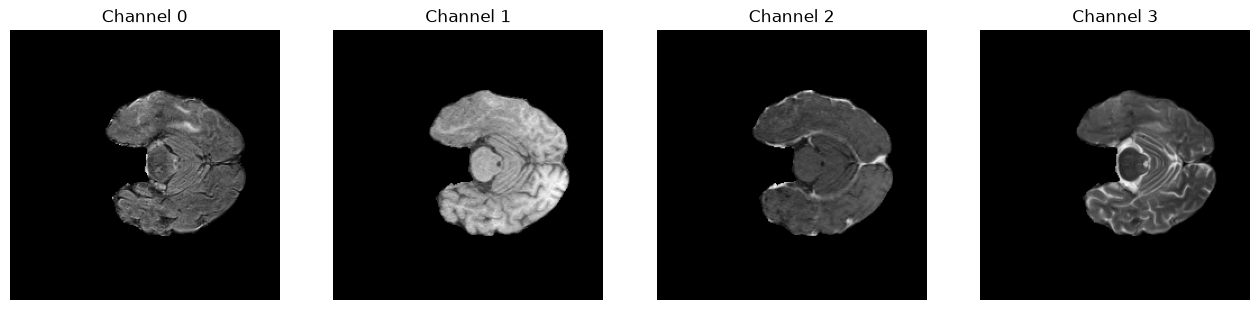

In [16]:
import h5py
import matplotlib.pyplot as plt
from pathlib import Path

file = list(Path("data").rglob("*.h5"))[0]

with h5py.File(file, "r") as f:
    image = f["image"][:]
    mask = f["mask"][:]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i in range(4):
    axes[i].imshow(image[:, :, i], cmap="gray")
    axes[i].set_title(f"Channel {i}")
    axes[i].axis("off")

plt.show()

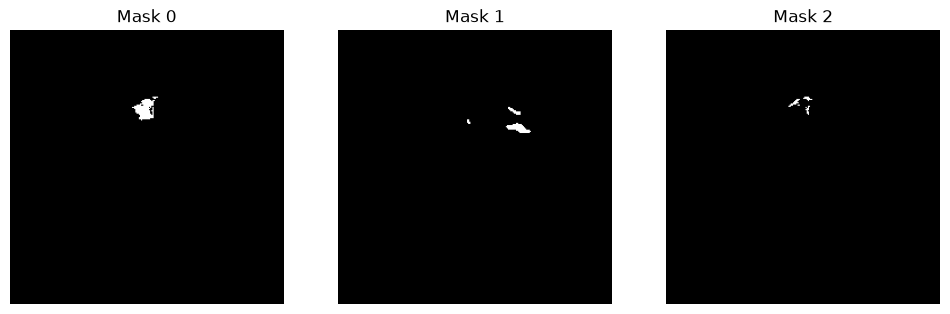

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(3):
    axes[i].imshow(mask[:, :, i], cmap="gray")
    axes[i].set_title(f"Mask {i}")
    axes[i].axis("off")

plt.show()

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/sample_metadata.csv")

train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["target"],
    random_state=42
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

print("\nValidation files:")
print(val_df["slice_path"].head(10).to_list())

Training samples: 1955
Validation samples: 345

Validation files:
['../input/brats2020-training-data/BraTS2020_training_data/content/data/volume_69_slice_70.h5', '../input/brats2020-training-data/BraTS2020_training_data/content/data/volume_320_slice_103.h5', '../input/brats2020-training-data/BraTS2020_training_data/content/data/volume_240_slice_68.h5', '../input/brats2020-training-data/BraTS2020_training_data/content/data/volume_16_slice_3.h5', '../input/brats2020-training-data/BraTS2020_training_data/content/data/volume_324_slice_27.h5', '../input/brats2020-training-data/BraTS2020_training_data/content/data/volume_84_slice_69.h5', '../input/brats2020-training-data/BraTS2020_training_data/content/data/volume_243_slice_92.h5', '../input/brats2020-training-data/BraTS2020_training_data/content/data/volume_192_slice_33.h5', '../input/brats2020-training-data/BraTS2020_training_data/content/data/volume_243_slice_77.h5', '../input/brats2020-training-data/BraTS2020_training_data/content/data/v

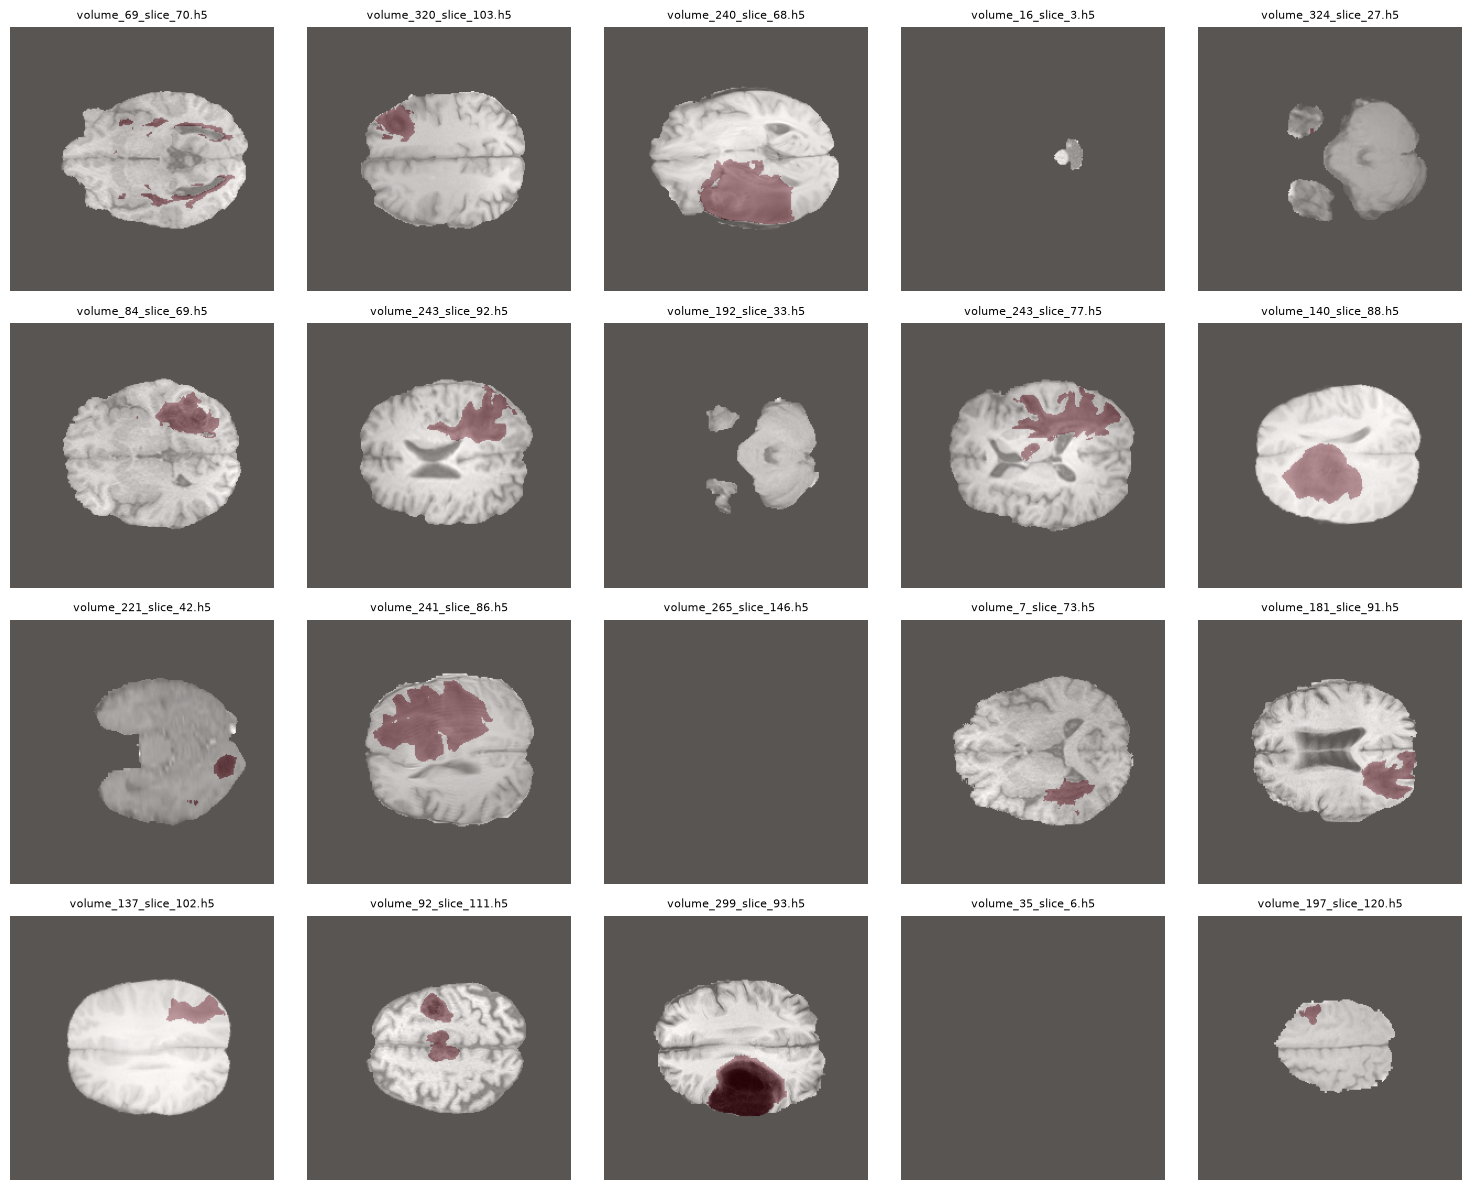

In [19]:
import os
import h5py
import matplotlib.pyplot as plt

files = val_df["slice_path"].tolist()[:20]

fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for ax, path in zip(axes.flat, files):
    filename = os.path.basename(path)
    local_path = os.path.join("data/slices", filename)

    with h5py.File(local_path, "r") as f:
        image = f["image"][:]
        mask = f["mask"][:]

    ax.imshow(image[..., 1], cmap="gray")
    ax.imshow(mask.max(axis=-1), cmap="Reds", alpha=0.35)
    ax.set_title(filename, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [20]:
import os
import shutil

os.makedirs("sample_data", exist_ok=True)

samples = [
    "volume_320_slice_103.h5",
    "volume_7_slice_73.h5",
    "volume_241_slice_86.h5"
]

for i, filename in enumerate(samples, 1):
    source = os.path.join("data", "slices", filename)
    destination = os.path.join("sample_data", f"sample_{i:03d}.h5")

    shutil.copy(source, destination)

print("3 sample files copied successfully.")

3 sample files copied successfully.


In [21]:
print(os.listdir("sample_data"))

['sample_001.h5', 'sample_002.h5', 'sample_003.h5']
